# 05 - Logistic Regression

Required grid:
- `C = [0.1, 0.5, 1.0, 2.0, 5.0]`
- `solver = ['lbfgs', 'saga']`
- `max_iter = [500, 1000]`
- `cv = 5`

Outputs are saved to `reports/05_logistic_regression/` and `models/lr_model.pkl`.


In [1]:
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
REPORT_DIR = ROOT / "reports" / "05_logistic_regression"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
LABELS = ["REAL (0)", "FAKE (1)"]


In [2]:
X_train = joblib.load(DATA_DIR / "X_train_tfidf.pkl")
X_val = joblib.load(DATA_DIR / "X_val_tfidf.pkl")
y_train = np.array(joblib.load(DATA_DIR / "y_train.pkl"))
y_val = np.array(joblib.load(DATA_DIR / "y_val.pkl"))

print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")
print("Train labels:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Val labels  :", dict(zip(*np.unique(y_val, return_counts=True))))


X_train: (27055, 10000) | X_val: (5798, 10000)
Train labels: {np.int64(0): np.int64(14836), np.int64(1): np.int64(12219)}
Val labels  : {np.int64(0): np.int64(3179), np.int64(1): np.int64(2619)}


In [3]:
lr = LogisticRegression(random_state=42)

param_grid = {
    "C": [0.1, 0.5, 1.0, 2.0, 5.0],
    "solver": ["lbfgs", "saga"],
    "max_iter": [500, 1000],
}

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)

start_time = time.time()
grid_search.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"Training/GridSearch time: {training_time:.2f} seconds")
print("Best params:", grid_search.best_params_)
print(f"Best CV weighted F1: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits


Training/GridSearch time: 10.56 seconds
Best params: {'C': 5.0, 'max_iter': 500, 'solver': 'saga'}
Best CV weighted F1: 0.9850


In [4]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_pred)
val_f1_weighted = f1_score(y_val, y_pred, average="weighted")
report_dict = classification_report(y_val, y_pred, target_names=LABELS, output_dict=True)
report_text = classification_report(y_val, y_pred, target_names=LABELS)
cm = confusion_matrix(y_val, y_pred)

print(report_text)
print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Validation weighted F1: {val_f1_weighted:.4f}")
print(cm)


              precision    recall  f1-score   support

    REAL (0)       0.99      0.99      0.99      3179
    FAKE (1)       0.99      0.98      0.99      2619

    accuracy                           0.99      5798
   macro avg       0.99      0.99      0.99      5798
weighted avg       0.99      0.99      0.99      5798

Validation accuracy: 0.9876
Validation weighted F1: 0.9876
[[3155   24]
 [  48 2571]]


In [5]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results.to_csv(REPORT_DIR / "gridsearch_results.csv", index=False)

pd.DataFrame(report_dict).transpose().to_csv(REPORT_DIR / "classification_report.csv")

metrics = {
    "best_params": grid_search.best_params_,
    "best_cv_f1_weighted": float(grid_search.best_score_),
    "validation_accuracy": float(val_accuracy),
    "validation_f1_weighted": float(val_f1_weighted),
    "training_time_seconds": float(training_time),
    "confusion_matrix": cm.tolist(),
}
with open(REPORT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

with open(REPORT_DIR / "training_log.txt", "w", encoding="utf-8") as f:
    f.write(f"Training/GridSearch time: {training_time:.2f} seconds\n")
    f.write(f"Best params: {grid_search.best_params_}\n")
    f.write(f"Best CV weighted F1: {grid_search.best_score_:.6f}\n")
    f.write(f"Validation accuracy: {val_accuracy:.6f}\n")
    f.write(f"Validation weighted F1: {val_f1_weighted:.6f}\n\n")
    f.write(report_text)

model_path = MODELS_DIR / "lr_model.pkl"
joblib.dump(best_model, model_path)
print("Saved model:", model_path)
print("Saved reports:", REPORT_DIR)


Saved model: /Users/duyhung/Desktop/CHUNG/HUST/Fake-News-Detection/models/lr_model.pkl
Saved reports: /Users/duyhung/Desktop/CHUNG/HUST/Fake-News-Detection/reports/05_logistic_regression


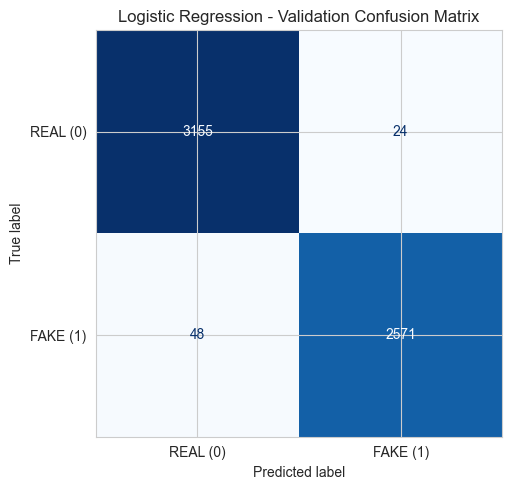

/var/folders/bt/x0xylfv90fz2hms4m1hdtcy80000gn/T/ipykernel_54106/3833207755.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, y="params_label", x="mean_test_score", ax=ax, palette="mako")


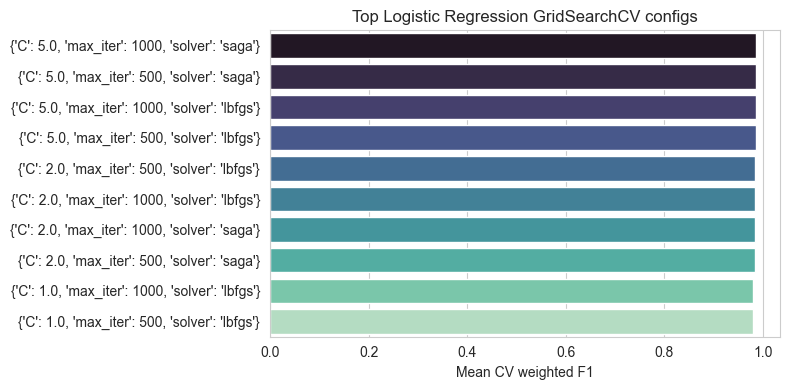

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
    cmap="Blues", ax=ax, values_format="d", colorbar=False
)
ax.set_title("Logistic Regression - Validation Confusion Matrix")
plt.tight_layout()
plt.savefig(REPORT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Compatibility image for older report links.
fig, ax = plt.subplots(figsize=(8, 4))
top = cv_results.sort_values("mean_test_score", ascending=False).head(10).copy()
top["params_label"] = top["params"].astype(str)
sns.barplot(data=top, y="params_label", x="mean_test_score", ax=ax, palette="mako")
ax.set_title("Top Logistic Regression GridSearchCV configs")
ax.set_xlabel("Mean CV weighted F1")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(REPORT_DIR / "top_gridsearch_configs.png", dpi=150, bbox_inches="tight")
plt.savefig(ROOT / "reports" / "lr_evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
